# Practical 12: Generative Adversarial Network (GAN)

**Problem Statement:** Develop a GAN to generate synthetic handwritten digit images.

**Activities:** Implement the Generator and Discriminator, train the GAN, and visualize generated images.

Epoch 1/5 complete
Epoch 2/5 complete
Epoch 3/5 complete
Epoch 4/5 complete
Epoch 5/5 complete


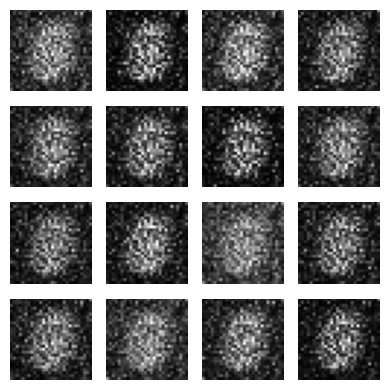

In [2]:
# Simple GAN for generating handwritten MNIST digits
import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt

# Load and normalize real digit images
(x_train, _), (_, _) = tf.keras.datasets.mnist.load_data()
x_train = (x_train.astype("float32") - 127.5) / 127.5
x_train = x_train.reshape(-1, 784)
dataset = tf.data.Dataset.from_tensor_slices(x_train).shuffle(60000).batch(128)

# Generator: noise -> fake image
G = tf.keras.Sequential([
    tf.keras.layers.Input(shape=(100,)),
    tf.keras.layers.Dense(128, activation="relu"),
    tf.keras.layers.Dense(784, activation="tanh")
])

# Discriminator: image -> real/fake probability
D = tf.keras.Sequential([
    tf.keras.layers.Input(shape=(784,)),
    tf.keras.layers.Dense(128, activation="relu"),
    tf.keras.layers.Dense(1, activation="sigmoid")
])

loss = tf.keras.losses.BinaryCrossentropy()
g_opt = tf.keras.optimizers.Adam(0.0002)
d_opt = tf.keras.optimizers.Adam(0.0002)

# Train both networks
for epoch in range(5):
    for real in dataset:
        noise = tf.random.normal((tf.shape(real)[0], 100))
        with tf.GradientTape() as gt, tf.GradientTape() as dt:
            fake = G(noise, training=True)
            d_loss = loss(tf.ones_like(D(real)), D(real)) + loss(tf.zeros_like(D(fake)), D(fake))
            g_loss = loss(tf.ones_like(D(fake)), D(fake))
        d_opt.apply_gradients(zip(dt.gradient(d_loss, D.trainable_variables), D.trainable_variables))
        g_opt.apply_gradients(zip(gt.gradient(g_loss, G.trainable_variables), G.trainable_variables))
    print(f"Epoch {epoch + 1}/5 complete")

# Visualize generated digits
images = G(tf.random.normal((16, 100)), training=False).numpy().reshape(16, 28, 28)
plt.figure(figsize=(4, 4))
for i, image in enumerate(images):
    plt.subplot(4, 4, i + 1)
    plt.imshow(image, cmap="gray")
    plt.axis("off")
plt.tight_layout()
plt.show()